In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('../data/spam.csv', encoding='latin-1')

# Keep only the columns we need
df = df[['v1', 'v2']]

# Rename columns to something readable
df.columns = ['label', 'message']

# Preview the first 5 rows
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
print(df.shape)

(5572, 2)


In [3]:
print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
print(df.isnull().sum())

label      0
message    0
dtype: int64


Matplotlib is building the font cache; this may take a moment.


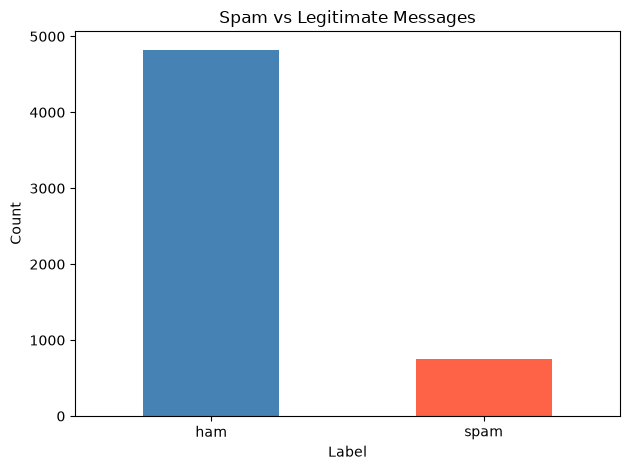

In [5]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Spam vs Legitimate Messages')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
# Add a column showing length of each message
df['message_length'] = df['message'].apply(len)

# Average length for spam vs ham
print(df.groupby('label')['message_length'].mean())

label
ham      71.023627
spam    138.866131
Name: message_length, dtype: float64


In [7]:
momo_fraud = [
    "Congratulations! Your MTN MoMo account has won GHS 500. Send your PIN to 024XXXXXXX to claim your reward.",
    "ALERT: Your Vodafone Cash account will be suspended. Call 055XXXXXXX and provide your PIN to verify.",
    "You have received GHS 200 from AirtelTigo promotion. Reply with your mobile money PIN to activate.",
    "MTN-GH: Dear customer, your SIM has won a cash prize. Dial *170# and enter code 8842 to claim.",
    "Your MoMo wallet is locked. To unlock send your 4-digit PIN to this number: 026XXXXXXX immediately.",
    "WINNER! You have been selected for our MTN loyalty reward of GHS 1000. Send PIN to confirm receipt.",
    "Security Alert: Unusual login on your MoMo account. Confirm your identity by replying with your PIN.",
    "AirtelTigo Money: Your account needs verification. Send your PIN and ID number to avoid deactivation.",
]

# Create a small dataframe from these
momo_df = pd.DataFrame({
    'label': ['spam'] * len(momo_fraud),
    'message': momo_fraud
})

# Add message length column
momo_df['message_length'] = momo_df['message'].apply(len)

# Merge with main dataset
df = pd.concat([df, momo_df], ignore_index=True)

print(f"Total messages after adding MoMo data: {len(df)}")
print(df['label'].value_counts())

Total messages after adding MoMo data: 5580
label
ham     4825
spam     755
Name: count, dtype: int64


In [8]:
import re
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove stopwords
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

df['cleaned'] = df['message'].apply(clean_text)

# Preview cleaned messages
df[['message', 'cleaned']].head(10)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,message,cleaned
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling weeks word back id like fu...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile months u r entitled update latest colou...


In [9]:
df.to_csv('../data/cleaned_sms.csv', index=False)
print("Cleaned data saved!")

Cleaned data saved!
